Señal cargada con éxito. Total de muestras: 78600

--- Parámetros HRV calculados ---
SDNN (Variabilidad Total): 69.81 ms
RMSSD (Actividad Parasimpática): 53.98 ms
Relación LF/HF: 0.94



/tmp/ipykernel_1676/2509319303.py:76: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(psd[lf_band], frequencies[lf_band])
/tmp/ipykernel_1676/2509319303.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz(psd[hf_band], frequencies[hf_band])


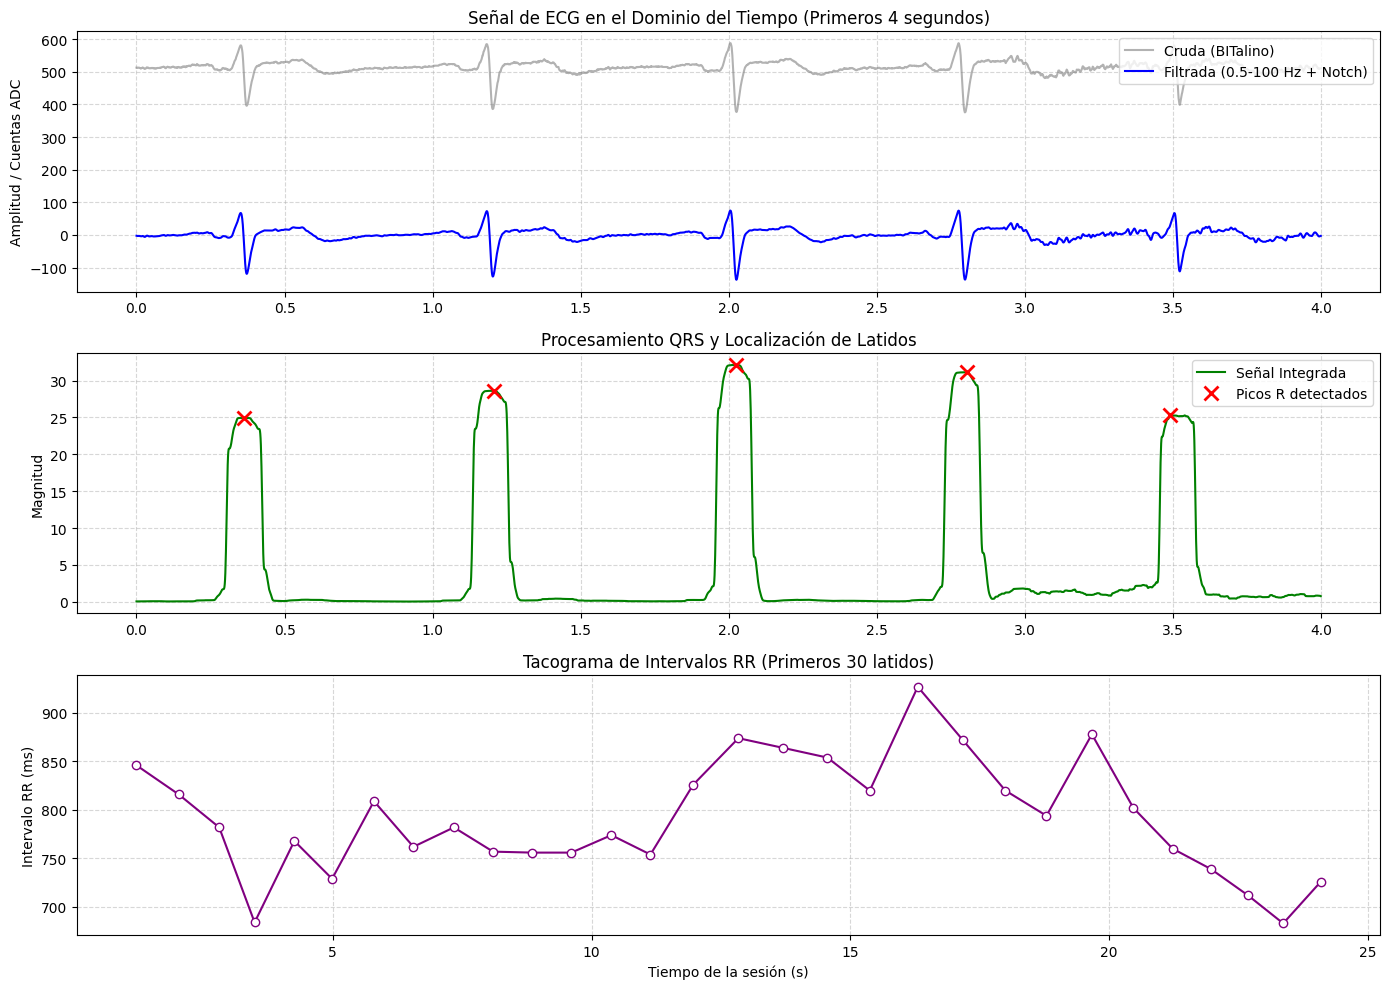

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, welch
from scipy.interpolate import interp1d

# ==========================================
# 1. CARGA DE DATOS DESDE BITALINO (.TXT)
# ==========================================

# ⚠️ CAMBIA ESTO: Pon el nombre exacto de tu archivo subido a Colab
nombre_archivo = 'opensignals_98D351FE862E_2026-06-12_11-43-37.txt'

# np.loadtxt ignora automáticamente las líneas de encabezado que empiezan con '#'
data = np.loadtxt(nombre_archivo, comments='#')

# BITalino guarda los datos en columnas. El ECG suele estar en una de las últimas columnas analógicas.
# Si solo encendiste un canal, suele ser la última (-1) o penúltima (-2) columna.
columna_ecg = -1  # ⚠️ Ajusta este índice si notas que la señal no es el ECG
signal = data[:, columna_ecg]

# Configuración de frecuencia de muestreo de tu BITalino
fs = 1000.0  # Hz (Por defecto suele ser 1000 Hz, ajústalo si usaste 100 o 10 Hz)

print(f"Señal cargada con éxito. Total de muestras: {len(signal)}")

# ==========================================
# 2. PROCESAMIENTO Y FILTRADO (0.5 - 100 Hz)
# ==========================================
nyquist = fs / 2.0
low = 0.5 / nyquist
high = 100 / nyquist

# Filtro Pasa Bandas Butterworth de orden 4
b_band, a_band = butter(4, [low, high], btype='band')
filtered_band_signal = filtfilt(b_band, a_band, signal)

# Filtro Notch (60 Hz para ruido de línea eléctrica, Q=30)
# Nota: Si estás en Europa/Sudamérica (algunos países) cambia a 50 Hz si es necesario.
q = 30
b_notch, a_notch = iirnotch(60, q, fs)
filtered_notch_signal = filtfilt(b_notch, a_notch, filtered_band_signal)

# ==========================================
# 3. EXTRACCIÓN DEL COMPLEJO QRS (Pan-Tompkins simplificado)
# ==========================================
diff_signal = np.diff(filtered_notch_signal, prepend=filtered_notch_signal[0])
squared_signal = diff_signal**2

window_length = int(0.12 * fs)
integrated_signal = np.convolve(squared_signal, np.ones(window_length)/window_length, mode='same')

# Obtención de intervalos RR
min_distance = int(0.6 * fs)  # Evita detectar ondas T u otras anomalías muy cercanas
peaks, _ = find_peaks(integrated_signal, distance=min_distance, height=np.mean(integrated_signal))

rr_interval_s = np.diff(peaks) / fs
rr_interval_ms = rr_interval_s * 1000

# ==========================================
# 4. CÁLCULO DE PARÁMETROS HRV
# ==========================================
sdnn = np.std(rr_interval_ms)
rmssd = np.sqrt(np.mean(np.diff(rr_interval_ms)**2))

time_peaks = peaks[1:] / fs
interp_func = interp1d(time_peaks, rr_interval_ms, kind='cubic', fill_value="extrapolate")
fs_resample = 4.0
time_resample = np.arange(time_peaks[0], time_peaks[-1], 1/fs_resample)
rr_resampled = interp_func(time_resample)

frequencies, psd = welch(rr_resampled, fs=fs_resample, nperseg=256)

lf_band = (frequencies >= 0.04) & (frequencies <= 0.15)
hf_band = (frequencies >= 0.15) & (frequencies <= 0.40)

lf_power = np.trapz(psd[lf_band], frequencies[lf_band])
hf_power = np.trapz(psd[hf_band], frequencies[hf_band])
lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0

# Mostrar métricas en consola
print("\n--- Parámetros HRV calculados ---")
print(f"SDNN (Variabilidad Total): {sdnn:.2f} ms")
print(f"RMSSD (Actividad Parasimpática): {rmssd:.2f} ms")
print(f"Relación LF/HF: {lf_hf_ratio:.2f}\n")

# ==========================================
# 5. VISUALIZACIÓN EN EL DOMINIO DEL TIEMPO
# ==========================================
n = np.arange(len(signal))
t = n / fs

# Definimos una ventana de visualización dinámica (primeros 4 segundos)
muestras_visibles = int(4 * fs)

plt.figure(figsize=(14, 10))

# Subplot 1: Señal Cruda vs Filtrada
plt.subplot(3, 1, 1)
plt.plot(t[:muestras_visibles], signal[:muestras_visibles], label="Cruda (BITalino)", alpha=0.6, color='gray')
plt.plot(t[:muestras_visibles], filtered_notch_signal[:muestras_visibles], label="Filtrada (0.5-100 Hz + Notch)", linewidth=1.5, color='blue')
plt.title("Señal de ECG en el Dominio del Tiempo (Primeros 4 segundos)")
plt.ylabel("Amplitud / Cuentas ADC")
plt.legend(loc="upper right")
plt.grid(ls="--", alpha=0.5)

# Subplot 2: Detección de picos R
plt.subplot(3, 1, 2)
plt.plot(t[:muestras_visibles], integrated_signal[:muestras_visibles], color='green', label="Señal Integrada")
visible_peaks = [p for p in peaks if p < muestras_visibles]
plt.plot(np.array(visible_peaks)/fs, integrated_signal[visible_peaks], 'rx', markersize=10, markeredgewidth=2, label="Picos R detectados")
plt.title("Procesamiento QRS y Localización de Latidos")
plt.ylabel("Magnitud")
plt.legend(loc="upper right")
plt.grid(ls="--", alpha=0.5)

# Subplot 3: Tacograma (Evolución de los intervalos RR)
plt.subplot(3, 1, 3)
# Mostramos los primeros 30 latidos para que sea legible
cant_latidos = min(30, len(rr_interval_ms))
plt.plot(time_peaks[:cant_latidos], rr_interval_ms[:cant_latidos], marker='o', linestyle='-', color='purple', mfc='white')
plt.title(f"Tacograma de Intervalos RR (Primeros {cant_latidos} latidos)")
plt.xlabel("Tiempo de la sesión (s)")
plt.ylabel("Intervalo RR (ms)")
plt.grid(ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

Señal cargada con éxito. Total de muestras: 78600
Duración total de la señal: 78.60 segundos

--- Parámetros HRV calculados ---
SDNN: 69.81 ms
RMSSD: 53.98 ms
Relación LF/HF: 0.94



/tmp/ipykernel_1676/1663584635.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(psd[lf_band], frequencies[lf_band])
/tmp/ipykernel_1676/1663584635.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz(psd[hf_band], frequencies[hf_band])


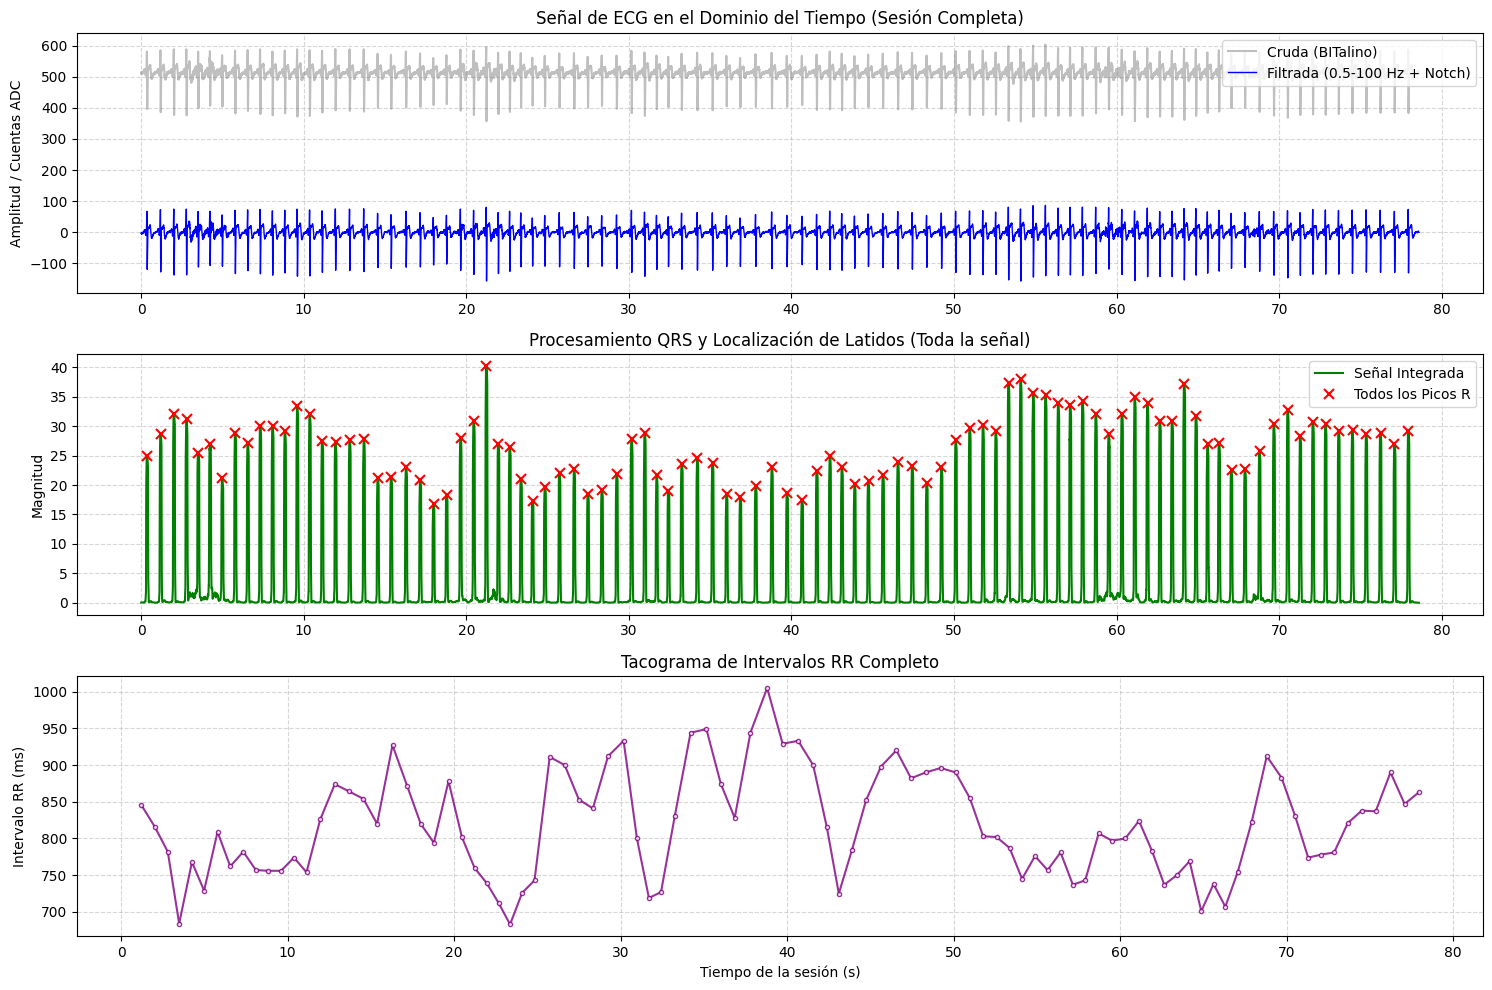

In [2]:
# BASELINE
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, welch
from scipy.interpolate import interp1d

# ==========================================
# 1. CARGA DE DATOS DESDE BITALINO (.TXT)
# ==========================================
nombre_archivo = 'opensignals_98D351FE862E_2026-06-12_11-43-37.txt'  # ⚠️ Cambia por el nombre de tu archivo
data = np.loadtxt(nombre_archivo, comments='#')

columna_ecg = -1  # ⚠️ Ajusta la columna de tu canal ECG si es necesario
signal = data[:, columna_ecg]
fs = 1000.0  # Frecuencia de muestreo en Hz

print(f"Señal cargada con éxito. Total de muestras: {len(signal)}")
print(f"Duración total de la señal: {len(signal)/fs:.2f} segundos")

# ==========================================
# 2. PROCESAMIENTO Y FILTRADO (0.5 - 100 Hz)
# ==========================================
nyquist = fs / 2.0
low = 0.5 / nyquist
high = 100 / nyquist

b_band, a_band = butter(4, [low, high], btype='band')
filtered_band_signal = filtfilt(b_band, a_band, signal)

q = 30
b_notch, a_notch = iirnotch(60, q, fs) # 60 Hz para ruido de línea
filtered_notch_signal = filtfilt(b_notch, a_notch, filtered_band_signal)

# ==========================================
# 3. EXTRACCIÓN DEL COMPLEJO QRS
# ==========================================
diff_signal = np.diff(filtered_notch_signal, prepend=filtered_notch_signal[0])
squared_signal = diff_signal**2

window_length = int(0.12 * fs)
integrated_signal = np.convolve(squared_signal, np.ones(window_length)/window_length, mode='same')

min_distance = int(0.6 * fs)
peaks, _ = find_peaks(integrated_signal, distance=min_distance, height=np.mean(integrated_signal))

rr_interval_s = np.diff(peaks) / fs
rr_interval_ms = rr_interval_s * 1000

# ==========================================
# 4. CÁLCULO DE PARÁMETROS HRV
# ==========================================
sdnn = np.std(rr_interval_ms)
rmssd = np.sqrt(np.mean(np.diff(rr_interval_ms)**2))

time_peaks = peaks[1:] / fs
interp_func = interp1d(time_peaks, rr_interval_ms, kind='cubic', fill_value="extrapolate")
fs_resample = 4.0
time_resample = np.arange(time_peaks[0], time_peaks[-1], 1/fs_resample)
rr_resampled = interp_func(time_resample)

frequencies, psd = welch(rr_resampled, fs=fs_resample, nperseg=256)

lf_band = (frequencies >= 0.04) & (frequencies <= 0.15)
hf_band = (frequencies >= 0.15) & (frequencies <= 0.40)

lf_power = np.trapz(psd[lf_band], frequencies[lf_band])
hf_power = np.trapz(psd[hf_band], frequencies[hf_band])
lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0

print("\n--- Parámetros HRV calculados ---")
print(f"SDNN: {sdnn:.2f} ms")
print(f"RMSSD: {rmssd:.2f} ms")
print(f"Relación LF/HF: {lf_hf_ratio:.2f}\n")

# ==========================================
# 5. VISUALIZACIÓN COMPLETA EN EL DOMINIO DEL TIEMPO
# ==========================================
n = np.arange(len(signal))
t = n / fs

plt.figure(figsize=(15, 10))

# Subplot 1: Señal Cruda vs Filtrada Completa
plt.subplot(3, 1, 1)
plt.plot(t, signal, label="Cruda (BITalino)", alpha=0.5, color='gray')
plt.plot(t, filtered_notch_signal, label="Filtrada (0.5-100 Hz + Notch)", linewidth=1, color='blue')
plt.title("Señal de ECG en el Dominio del Tiempo (Sesión Completa)")
plt.ylabel("Amplitud / Cuentas ADC")
plt.legend(loc="upper right")
plt.grid(ls="--", alpha=0.5)

# Subplot 2: Todos los Picos Detectados
plt.subplot(3, 1, 2)
plt.plot(t, integrated_signal, color='green', label="Señal Integrada")
plt.plot(peaks / fs, integrated_signal[peaks], 'rx', markersize=7, markeredgewidth=1.5, label="Todos los Picos R")
plt.title("Procesamiento QRS y Localización de Latidos (Toda la señal)")
plt.ylabel("Magnitud")
plt.legend(loc="upper right")
plt.grid(ls="--", alpha=0.5)

# Subplot 3: Tacograma Completo
plt.subplot(3, 1, 3)
# Se reduce el tamaño del marcador (markersize=3) para que no se sature visualmente si es muy larga
plt.plot(time_peaks, rr_interval_ms, marker='o', markersize=3, linestyle='-', color='purple', mfc='white', alpha=0.8)
plt.title("Tacograma de Intervalos RR Completo")
plt.xlabel("Tiempo de la sesión (s)")
plt.ylabel("Intervalo RR (ms)")
plt.grid(ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

Señal cargada con éxito. Total de muestras: 59550
Duración total de la señal: 59.55 segundos

--- Parámetros HRV calculados ---
SDNN: 55.28 ms
RMSSD: 51.40 ms
Relación LF/HF: 1.05



/tmp/ipykernel_1676/877643952.py:60: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 232, using nperseg = 232
  frequencies, psd = welch(rr_resampled, fs=fs_resample, nperseg=256)
/tmp/ipykernel_1676/877643952.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(psd[lf_band], frequencies[lf_band])
/tmp/ipykernel_1676/877643952.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz(psd[hf_band], frequencies[hf_band])


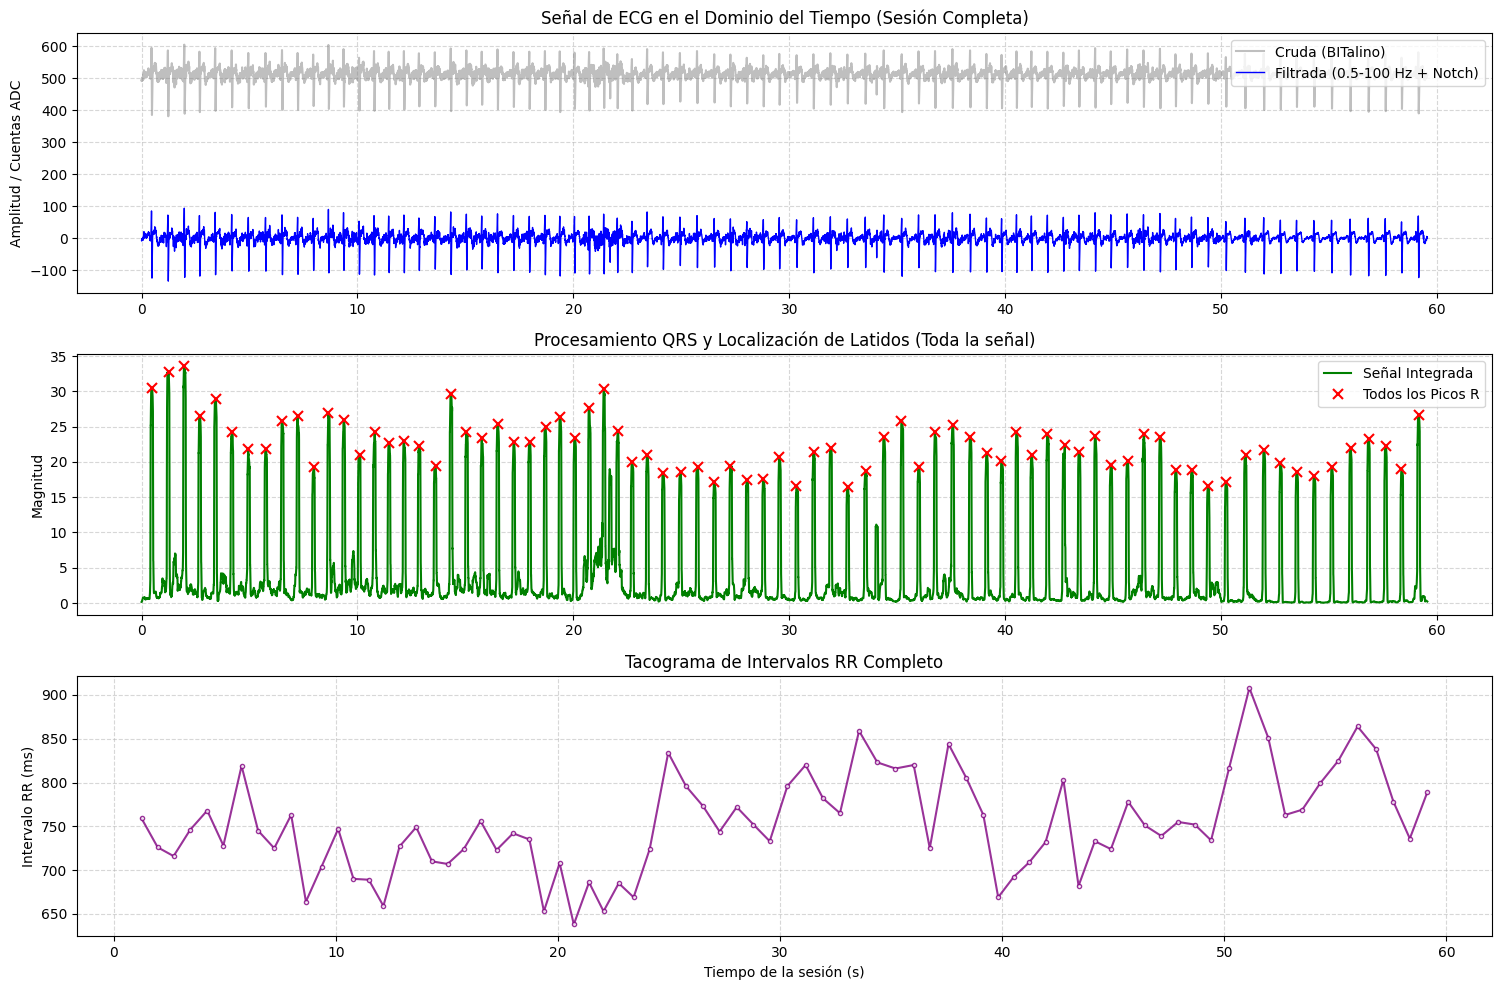

In [3]:
#BLOQUE 1
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, welch
from scipy.interpolate import interp1d

# ==========================================
# 1. CARGA DE DATOS DESDE BITALINO (.TXT)
# ==========================================
nombre_archivo = 'opensignals_98D351FE862E_2026-06-12_11-49-36.txt'  # ⚠️ Cambia por el nombre de tu archivo
data = np.loadtxt(nombre_archivo, comments='#')

columna_ecg = -1  # ⚠️ Ajusta la columna de tu canal ECG si es necesario
signal = data[:, columna_ecg]
fs = 1000.0  # Frecuencia de muestreo en Hz

print(f"Señal cargada con éxito. Total de muestras: {len(signal)}")
print(f"Duración total de la señal: {len(signal)/fs:.2f} segundos")

# ==========================================
# 2. PROCESAMIENTO Y FILTRADO (0.5 - 100 Hz)
# ==========================================
nyquist = fs / 2.0
low = 0.5 / nyquist
high = 100 / nyquist

b_band, a_band = butter(4, [low, high], btype='band')
filtered_band_signal = filtfilt(b_band, a_band, signal)

q = 30
b_notch, a_notch = iirnotch(60, q, fs) # 60 Hz para ruido de línea
filtered_notch_signal = filtfilt(b_notch, a_notch, filtered_band_signal)

# ==========================================
# 3. EXTRACCIÓN DEL COMPLEJO QRS
# ==========================================
diff_signal = np.diff(filtered_notch_signal, prepend=filtered_notch_signal[0])
squared_signal = diff_signal**2

window_length = int(0.12 * fs)
integrated_signal = np.convolve(squared_signal, np.ones(window_length)/window_length, mode='same')

min_distance = int(0.6 * fs)
peaks, _ = find_peaks(integrated_signal, distance=min_distance, height=np.mean(integrated_signal))

rr_interval_s = np.diff(peaks) / fs
rr_interval_ms = rr_interval_s * 1000

# ==========================================
# 4. CÁLCULO DE PARÁMETROS HRV
# ==========================================
sdnn = np.std(rr_interval_ms)
rmssd = np.sqrt(np.mean(np.diff(rr_interval_ms)**2))

time_peaks = peaks[1:] / fs
interp_func = interp1d(time_peaks, rr_interval_ms, kind='cubic', fill_value="extrapolate")
fs_resample = 4.0
time_resample = np.arange(time_peaks[0], time_peaks[-1], 1/fs_resample)
rr_resampled = interp_func(time_resample)

frequencies, psd = welch(rr_resampled, fs=fs_resample, nperseg=256)

lf_band = (frequencies >= 0.04) & (frequencies <= 0.15)
hf_band = (frequencies >= 0.15) & (frequencies <= 0.40)

lf_power = np.trapz(psd[lf_band], frequencies[lf_band])
hf_power = np.trapz(psd[hf_band], frequencies[hf_band])
lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0

print("\n--- Parámetros HRV calculados ---")
print(f"SDNN: {sdnn:.2f} ms")
print(f"RMSSD: {rmssd:.2f} ms")
print(f"Relación LF/HF: {lf_hf_ratio:.2f}\n")

# ==========================================
# 5. VISUALIZACIÓN COMPLETA EN EL DOMINIO DEL TIEMPO
# ==========================================
n = np.arange(len(signal))
t = n / fs

plt.figure(figsize=(15, 10))

# Subplot 1: Señal Cruda vs Filtrada Completa
plt.subplot(3, 1, 1)
plt.plot(t, signal, label="Cruda (BITalino)", alpha=0.5, color='gray')
plt.plot(t, filtered_notch_signal, label="Filtrada (0.5-100 Hz + Notch)", linewidth=1, color='blue')
plt.title("Señal de ECG en el Dominio del Tiempo (Sesión Completa)")
plt.ylabel("Amplitud / Cuentas ADC")
plt.legend(loc="upper right")
plt.grid(ls="--", alpha=0.5)

# Subplot 2: Todos los Picos Detectados
plt.subplot(3, 1, 2)
plt.plot(t, integrated_signal, color='green', label="Señal Integrada")
plt.plot(peaks / fs, integrated_signal[peaks], 'rx', markersize=7, markeredgewidth=1.5, label="Todos los Picos R")
plt.title("Procesamiento QRS y Localización de Latidos (Toda la señal)")
plt.ylabel("Magnitud")
plt.legend(loc="upper right")
plt.grid(ls="--", alpha=0.5)

# Subplot 3: Tacograma Completo
plt.subplot(3, 1, 3)
# Se reduce el tamaño del marcador (markersize=3) para que no se sature visualmente si es muy larga
plt.plot(time_peaks, rr_interval_ms, marker='o', markersize=3, linestyle='-', color='purple', mfc='white', alpha=0.8)
plt.title("Tacograma de Intervalos RR Completo")
plt.xlabel("Tiempo de la sesión (s)")
plt.ylabel("Intervalo RR (ms)")
plt.grid(ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

Señal cargada con éxito. Total de muestras: 74100
Duración total de la señal: 74.10 segundos

--- Parámetros HRV calculados ---
SDNN: 60.97 ms
RMSSD: 58.83 ms
Relación LF/HF: 1.49



/tmp/ipykernel_1676/2895916568.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(psd[lf_band], frequencies[lf_band])
/tmp/ipykernel_1676/2895916568.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz(psd[hf_band], frequencies[hf_band])


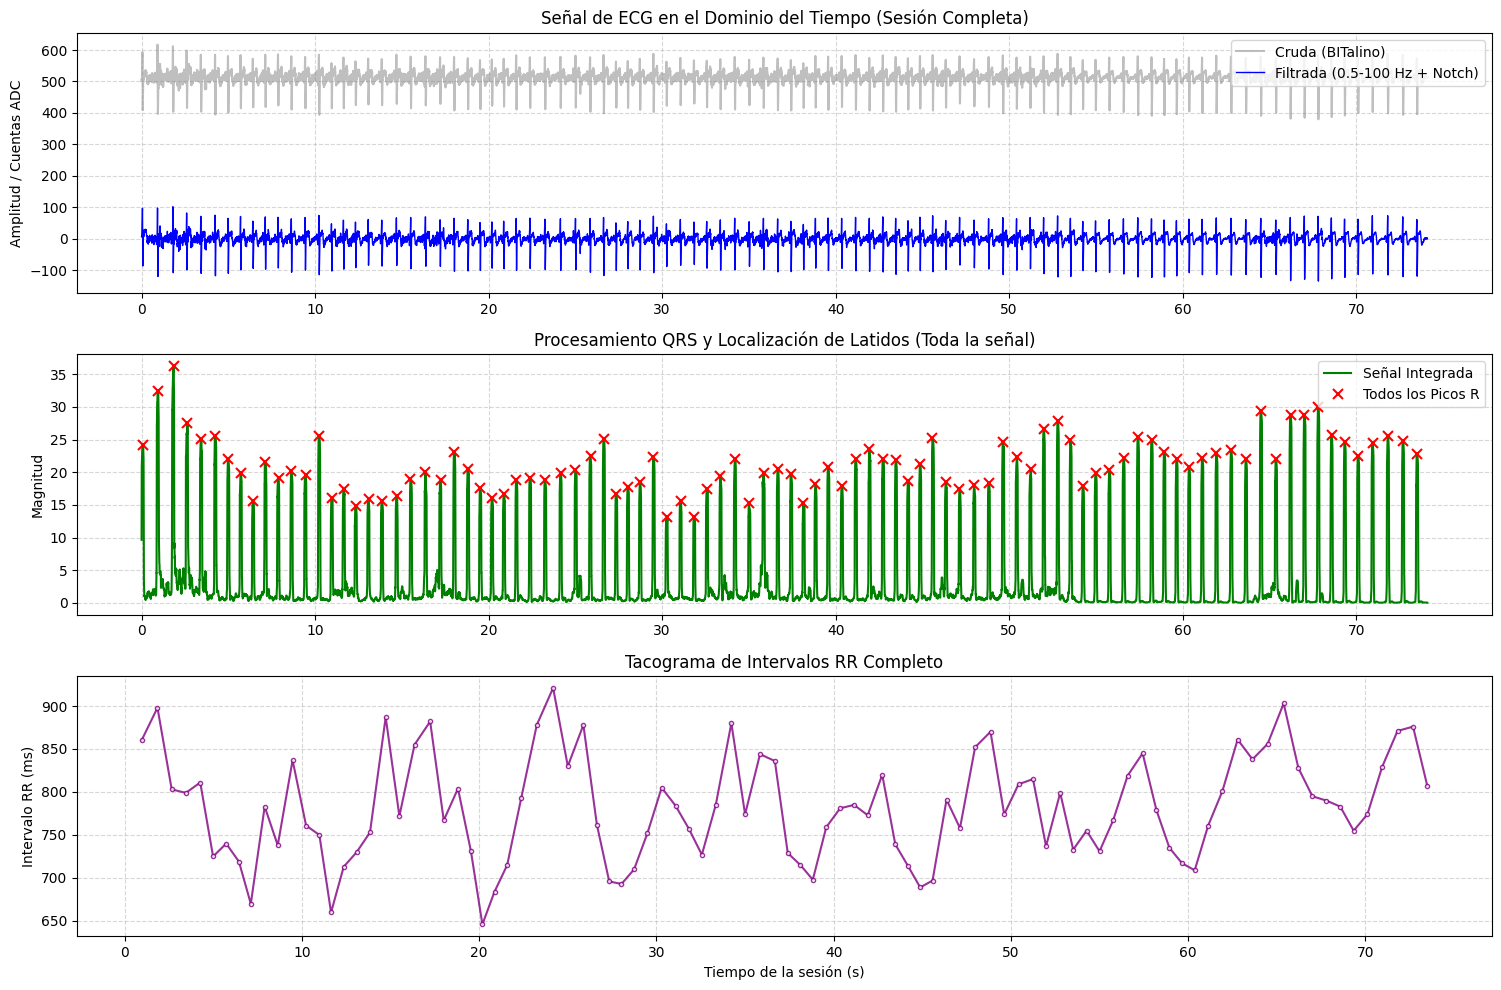

In [4]:
#BLOQUE 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, welch
from scipy.interpolate import interp1d

# ==========================================
# 1. CARGA DE DATOS DESDE BITALINO (.TXT)
# ==========================================
nombre_archivo = 'opensignals_98D351FE862E_2026-06-12_11-51-12.txt'  # ⚠️ Cambia por el nombre de tu archivo
data = np.loadtxt(nombre_archivo, comments='#')

columna_ecg = -1  # ⚠️ Ajusta la columna de tu canal ECG si es necesario
signal = data[:, columna_ecg]
fs = 1000.0  # Frecuencia de muestreo en Hz

print(f"Señal cargada con éxito. Total de muestras: {len(signal)}")
print(f"Duración total de la señal: {len(signal)/fs:.2f} segundos")

# ==========================================
# 2. PROCESAMIENTO Y FILTRADO (0.5 - 100 Hz)
# ==========================================
nyquist = fs / 2.0
low = 0.5 / nyquist
high = 100 / nyquist

b_band, a_band = butter(4, [low, high], btype='band')
filtered_band_signal = filtfilt(b_band, a_band, signal)

q = 30
b_notch, a_notch = iirnotch(60, q, fs) # 60 Hz para ruido de línea
filtered_notch_signal = filtfilt(b_notch, a_notch, filtered_band_signal)

# ==========================================
# 3. EXTRACCIÓN DEL COMPLEJO QRS
# ==========================================
diff_signal = np.diff(filtered_notch_signal, prepend=filtered_notch_signal[0])
squared_signal = diff_signal**2

window_length = int(0.12 * fs)
integrated_signal = np.convolve(squared_signal, np.ones(window_length)/window_length, mode='same')

min_distance = int(0.6 * fs)
peaks, _ = find_peaks(integrated_signal, distance=min_distance, height=np.mean(integrated_signal))

rr_interval_s = np.diff(peaks) / fs
rr_interval_ms = rr_interval_s * 1000

# ==========================================
# 4. CÁLCULO DE PARÁMETROS HRV
# ==========================================
sdnn = np.std(rr_interval_ms)
rmssd = np.sqrt(np.mean(np.diff(rr_interval_ms)**2))

time_peaks = peaks[1:] / fs
interp_func = interp1d(time_peaks, rr_interval_ms, kind='cubic', fill_value="extrapolate")
fs_resample = 4.0
time_resample = np.arange(time_peaks[0], time_peaks[-1], 1/fs_resample)
rr_resampled = interp_func(time_resample)

frequencies, psd = welch(rr_resampled, fs=fs_resample, nperseg=256)

lf_band = (frequencies >= 0.04) & (frequencies <= 0.15)
hf_band = (frequencies >= 0.15) & (frequencies <= 0.40)

lf_power = np.trapz(psd[lf_band], frequencies[lf_band])
hf_power = np.trapz(psd[hf_band], frequencies[hf_band])
lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0

print("\n--- Parámetros HRV calculados ---")
print(f"SDNN: {sdnn:.2f} ms")
print(f"RMSSD: {rmssd:.2f} ms")
print(f"Relación LF/HF: {lf_hf_ratio:.2f}\n")

# ==========================================
# 5. VISUALIZACIÓN COMPLETA EN EL DOMINIO DEL TIEMPO
# ==========================================
n = np.arange(len(signal))
t = n / fs

plt.figure(figsize=(15, 10))

# Subplot 1: Señal Cruda vs Filtrada Completa
plt.subplot(3, 1, 1)
plt.plot(t, signal, label="Cruda (BITalino)", alpha=0.5, color='gray')
plt.plot(t, filtered_notch_signal, label="Filtrada (0.5-100 Hz + Notch)", linewidth=1, color='blue')
plt.title("Señal de ECG en el Dominio del Tiempo (Sesión Completa)")
plt.ylabel("Amplitud / Cuentas ADC")
plt.legend(loc="upper right")
plt.grid(ls="--", alpha=0.5)

# Subplot 2: Todos los Picos Detectados
plt.subplot(3, 1, 2)
plt.plot(t, integrated_signal, color='green', label="Señal Integrada")
plt.plot(peaks / fs, integrated_signal[peaks], 'rx', markersize=7, markeredgewidth=1.5, label="Todos los Picos R")
plt.title("Procesamiento QRS y Localización de Latidos (Toda la señal)")
plt.ylabel("Magnitud")
plt.legend(loc="upper right")
plt.grid(ls="--", alpha=0.5)

# Subplot 3: Tacograma Completo
plt.subplot(3, 1, 3)
# Se reduce el tamaño del marcador (markersize=3) para que no se sature visualmente si es muy larga
plt.plot(time_peaks, rr_interval_ms, marker='o', markersize=3, linestyle='-', color='purple', mfc='white', alpha=0.8)
plt.title("Tacograma de Intervalos RR Completo")
plt.xlabel("Tiempo de la sesión (s)")
plt.ylabel("Intervalo RR (ms)")
plt.grid(ls="--", alpha=0.5)

plt.tight_layout()
plt.show()